<a href="https://colab.research.google.com/github/Dearsley/computer_math/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%965_%D0%91%D0%B8%D0%B1%D0%BB%D0%B8%D0%BE%D1%82%D0%B5%D0%BA%D0%B0_Pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическая работа №5. Библиотека Pandas. Визуальный анализ данных

## Комплексное задание №1. Применение основных методов для анализа данных

1. Скачайте этот блокнот к себе.
2. Заполните пропущенные ячейки, отвечая на заданные вопросы. Там должен быть код! (если не сказано обратное)
3. Сохраните результат в своём гитхаб репозитории.

#### Полезная литература
- [**Блокнот с теорией**](https://colab.research.google.com/drive/1SLqmaYz4xEsxVV-LGwb3ityheBTzHJQu?usp=sharing)
- http://pandas.pydata.org/pandas-docs/stable/10min.html
- https://pandas.pydata.org/pandas-docs/stable/indexing.html
- https://pandas.pydata.org/pandas-docs/stable/missing_data.html

В этом задании мы с Вами рассмотрим датасет [Adult Data Set](https://archive.ics.uci.edu/ml/datasets/Adult).
Основывается он на данных переписи населения 1994 года в США.

Расшифровка содержимого колонок:

- age: continuous.
- workclass: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked.
- fnlwgt: continuous. sampling weight, more here: SIPP Weighting.
- education: Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool.
- education-num: continuous.
- marital-status: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse.
- occupation: Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces.
- relationship: Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried.
- race: White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black.
- sex: Female, Male.
- capital-gain: continuous. Income from investment sources, apart from wages/salary.
- capital-loss: continuous. Losses from investment sources, apart from wages/salary.
- hours-per-week: continuous.
- native-country: United-States, Cambodia, England, Puerto-Rico, Canada, Germany, Outlying-US(Guam-USVI-etc), India, Japan, Greece, South, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia, El-Salvador, Trinadad&Tobago, Peru, Hong, Holand-Netherlands.

In [ ]:
%matplotlib inline
import pandas as pd
pd.__version__

'2.2.3'

Если вы увидели warning, не переживайте, всё хорошо.
- https://stackoverflow.com/questions/40845304/runtimewarning-numpy-dtype-size-changed-may-indicate-binary-incompatibility
- https://github.com/numpy/numpy/pull/432

In [ ]:
columns='age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income'.split(',')
# df = pd.read_csv('../../data/adult.csv.gz', na_values='?') # можно загрузить из файла или URL
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data', na_values=' ?', names=columns)

for column in df.select_dtypes(include=['object', 'str']).columns:
    df[column] = df[column].str.strip()

df.head()

TypeError: string dtypes are not allowed, use 'object' instead

1) Выведите последние 10 элеметнов датасета

In [ ]:
df.tail(10)

2) Сколько колонок и сколько строк в этом датасете?

In [ ]:
print('Количество строк:', df.shape[0])
print('Количество колонок:', df.shape[1])

3) Какие типы данных у элементов этого датасета?

In [ ]:
df.dtypes

4) Какие признаки имеют пропуски?

In [ ]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

5) Как вы думаете, с чем связаны пропуски этих значение. Напишите развернутый ответ в ячейке ниже.

Ваш ответ:

Пропуски есть в столбцах `workclass`, `occupation` и `native.country`. Скорее всего, некоторые участники переписи не указали место работы, профессию или страну рождения. Часть значений могла быть неизвестна при сборе данных.

6) Какие и сколько различных рабочих классов workclass представлено в выборке?

In [ ]:
print('Количество рабочих классов:', df['workclass'].nunique())
df['workclass'].value_counts(dropna=False)

7) Какой средний возраст женщин и мужчин?

In [ ]:
df.groupby('sex')['age'].mean()

8) Постройте гистограмму(bar) распределения образования людей (education)

In [ ]:
from matplotlib import pyplot as plt

df['education'].value_counts().plot(kind='bar', figsize=(10, 5))
plt.xlabel('Образование')
plt.ylabel('Количество людей')
plt.show()

9) Каковы средние значения и среднеквадратичные отклонения возраста тех, кто получает более 50K в год (признак income) и тех, кто получает менее 50K в год?

In [ ]:
df.groupby('income')['age'].agg(['mean', 'std'])

10) Правда ли, что люди, которые получают больше 50k, имеют как минимум высшее образование? (признак education - Bachelors, Prof-school, Assoc-acdm, Assoc-voc, Masters или Doctorate)

In [ ]:
higher_education = ['Bachelors', 'Prof-school', 'Assoc-acdm', 'Assoc-voc', 'Masters', 'Doctorate']
other_education = df[(df['income'] == '>50K') & (~df['education'].isin(higher_education))]
other_education['education'].value_counts()

11) Среди кого больше доля зарабатывающих много (>50K): среди женатых или холостых мужчин (признак marital-status)? Женатыми считаем тех, у кого marital-status начинается с Married (Married-civ-spouse, Married-spouse-absent или Married-AF-spouse), остальных считаем холостыми.

In [ ]:
men = df[df['sex'] == 'Male'].copy()
men['married'] = men['marital.status'].str.startswith('Married')
men['high_income'] = men['income'] == '>50K'
men.groupby('married')['high_income'].mean()

12) Постройте [сводную таблицу](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.pivot_table.html) для отображения зависимостей среднего времени работы (hours.per.week) с доходом (income) для каждой страны (native.country).  


> Пример фрагмента таблицы:



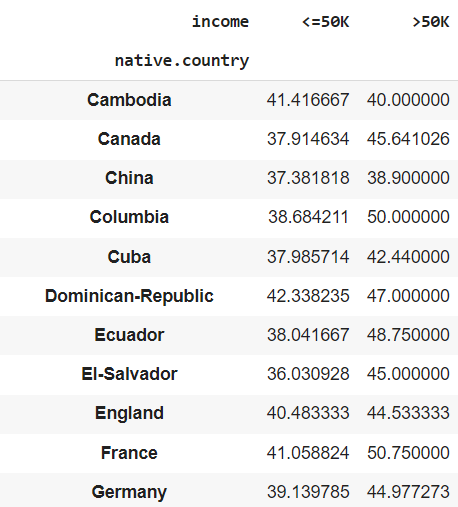

In [ ]:
pd.pivot_table(df, values='hours.per.week', index='native.country', columns='income', aggfunc='mean')

13) Постройте сводную таблицу для сравнения уровня образования и разности между capital.gain и capital.loss по следующему алгоритму:&nbsp;  
1. Создайте вспомогательную таблицу (датафрейм) и добавьте в неё столбец "education" из целевой таблицы
2. Добавьте во вспомогательную таблицу ещё один столбец "capital.diff", значиниями которого будут являться разности столбцов capital.gain и capital.loss целевой таблицы
3. Удалите во вспомогательной таблице все строки, в которых значение столбца "capital.diff" равно нулю  
&nbsp; Подсказка:
```
summary_table = summary_table[summary_table['capital.diff'] != 0 ]
```
4. Для набора значений из столбца "capital.diff", необходимо сформировать 10 категорий (кластеров), это можно сделать с помощью математических функций, типа log, извлечение корня N-ой степени и округления, для последующего перехода к категориальным признакам.  
  * В нашем случае, можно воспользоваться методом [pd.qcut()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.qcut.html) и равномерно разделить наш набор данных на целевое количество категорий
5. Добавьте во вспомогательную таблицу столбец "categories", и проинициализируйте его значениями категорий, которые возвращает метод pd.qcut()  
&nbsp; Пример:
```
summary_table['categories'] = pd.qcut(summary_table["capital.diff"], q = 10)

6. Постройте сводную таблицу с помощью метода pivot_table(),

Примерная структура таблицы (в качестве значений выводится количество людей, относящихся к той или иной группе):

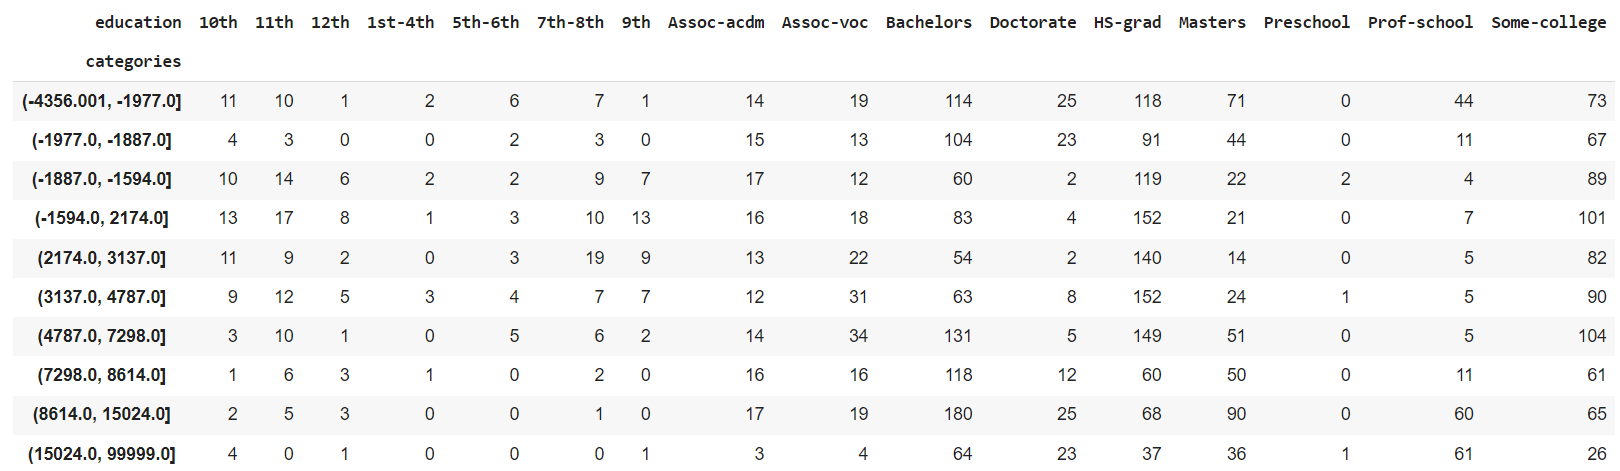

In [ ]:
summary_table = pd.DataFrame()
summary_table['education'] = df['education']
summary_table['capital.diff'] = df['capital.gain'] - df['capital.loss']
summary_table = summary_table[summary_table['capital.diff'] != 0]
summary_table['categories'] = pd.qcut(summary_table['capital.diff'], q=10)
pd.pivot_table(summary_table, values='capital.diff', index='education', columns='categories', aggfunc='count', fill_value=0, observed=False)

14) Женщины из каких стран получают в среднем большую зарплату (>50K) чаще.

In [ ]:
women = df[df['sex'] == 'Female'].copy()
women['high_income'] = women['income'] == '>50K'
women.groupby('native.country')['high_income'].mean().sort_values(ascending=False).head(10)

15) Создайте случайную колонку - magic_salary, которую нужно будет вычислить следующим образом: если зарплата небольшая (<50K), тогда случайно выберите число из диапазона [0,50]. Если зарплата выше 50K тогда из диапазона [51, 200]. Посчитайте среднюю зарплату в час для групп людей с одни уровнем образования на основе нашей случайной колонки magic_salary

In [ ]:
import numpy as np

np.random.seed(42)
magic_salary = []

for income in df['income']:
    if income == '<=50K':
        magic_salary.append(np.random.randint(0, 51))
    else:
        magic_salary.append(np.random.randint(51, 201))

df['magic_salary'] = magic_salary
df.groupby('education')['magic_salary'].mean().sort_values(ascending=False)

## Комплексное задание №2. Визуальный анализ данных. Часть 1

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline

В этом задании Вам предлагается провести визуальный анализ датасета о прокатах велосипедов https://www.kaggle.com/c/bike-sharing-demand/data. Оригинальная задача предполагает построение модели предсказания количества прокатов в городе в зависимости от погоды.

Для каждого дня проката известны следующие признаки (как они были указаны в источнике данных):
- season: 1 - весна, 2 - лето, 3 - осень, 4 - зима
- yr: 0 - 2011, 1 - 2012
- mnth: от 1 до 12
- holiday: 0 - нет праздника, 1 - есть праздник
- weekday: от 0 до 6
- workingday: 0 - нерабочий день, 1 - рабочий день
- weathersit: оценка благоприятности погоды от 1 (чистый, ясный день) до 4 (ливень, туман)
- temp: температура в Цельсиях
- atemp: температура по ощущениям в Цельсиях
- hum: влажность
- windspeed(mph): скорость ветра в милях в час
- windspeed(ms): скорость ветра в метрах в секунду
- cnt: количество арендованных велосипедов (это целевой признак, его мы будем предсказывать)

Загрузите самостоятельно(!), с помощью pandas файл `bikes_rent.csv.gz` и выведите первые 5 строк. Ознакомьтесь с данными с помощью функций describe и info.

In [ ]:
df = pd.read_csv("train.csv")
df["datetime"] = pd.to_datetime(df['datetime'])
df["mnth"] = df['datetime'].dt.month
df["yr"] = df["datetime"].dt.year
df["weekday"] = df["datetime"].dt.weekday
del df["casual"]
del df["registered"]
del df["datetime"]
df = df.rename(columns={
    "humidity": "hum",
    "weather": "weathersit",
    "count": "cnt"
})

display(df.head())
df.describe()

,season,holiday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,mnth,yr,weekday
0,1,0,0,1,9.84,14.395,81,0.0,16,1,2011,5
1,1,0,0,1,9.02,13.635,80,0.0,40,1,2011,5
2,1,0,0,1,9.02,13.635,80,0.0,32,1,2011,5
3,1,0,0,1,9.84,14.395,75,0.0,13,1,2011,5
4,1,0,0,1,9.84,14.395,75,0.0,1,1,2011,5


,season,holiday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,mnth,yr,weekday
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,191.574132,6.521495,2011.501929,3.013963
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,181.144454,3.444373,0.500019,2.004585
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,1.000000,1.000000,2011.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,42.000000,4.000000,2011.000000,1.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,145.000000,7.000000,2012.000000,3.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,284.000000,10.000000,2012.000000,5.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,977.000000,12.000000,2012.000000,6.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      10886 non-null  int64  
 1   holiday     10886 non-null  int64  
 2   workingday  10886 non-null  int64  
 3   weathersit  10886 non-null  int64  
 4   temp        10886 non-null  float64
 5   atemp       10886 non-null  float64
 6   hum         10886 non-null  int64  
 7   windspeed   10886 non-null  float64
 8   cnt         10886 non-null  int64  
 9   mnth        10886 non-null  int32  
 10  yr          10886 non-null  int32  
 11  weekday     10886 non-null  int32  
dtypes: float64(3), int32(3), int64(6)
memory usage: 893.1 KB


Давайте посмотрим на графиках, как целевой признак зависит количество прокатов (cnt) зависит от остальных признаков `df.columns[:-1]`.

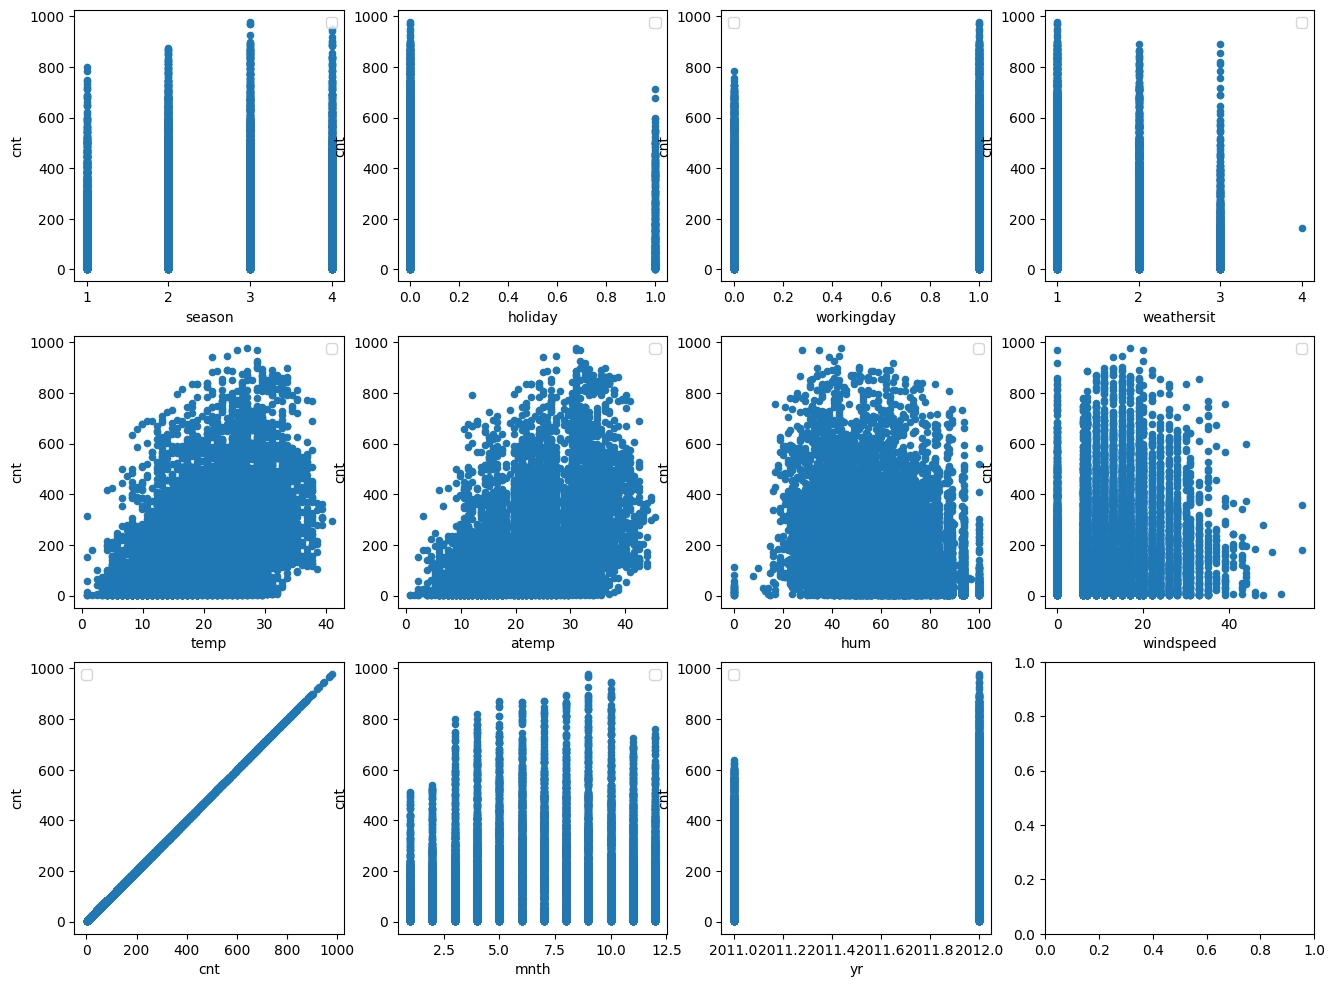

In [ ]:
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(16, 12))
for idx, feature in enumerate(df.columns[:-1]):
     df.plot(feature, "cnt", subplots=True, kind="scatter", ax=axes[idx // 4, idx % 4])

### 1. Ответьте на вопросы:

#### Каков характер зависимости числа прокатов от месяца?





<Axes: xlabel='mnth'>

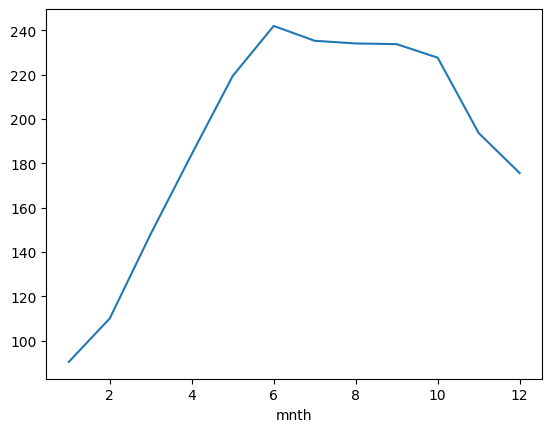

In [ ]:
df.groupby("mnth")["cnt"].mean().plot()

Ответ:

Зависимость сезонная и нелинейная: число прокатов растёт от начала года к лету, а затем плавно снижается к осени и резко к зиме.

#### Укажите один или два признака, от которых число прокатов скорее всего зависит линейно
_(чем больше значение, тем больше прокатов или наоборот, например)_

Можете проверить результат с помощью lnplot.



<Axes: xlabel='yr'>

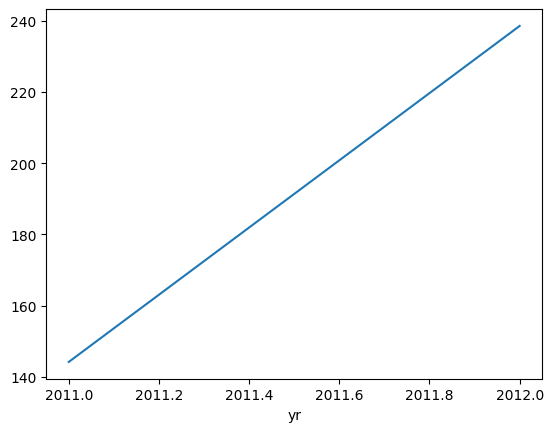

In [ ]:
df.groupby("yr")["cnt"].mean().plot()

Ответ:

Наиболее похожая на линейную положительная зависимость наблюдается y `yr`.

### 2. Корреляционная матрица

Напомним, что корреляция отражает взаимосвязь двух случайных величин. Она бывает положительная и отрицательная. Чем ближе коэффициент корреляции к нулю, тем меньше взаимосвязь. Чем больше абсолютная корреляци, тем взаимосвязь больше.

Постройте heatmap корреляционной матрицы. Матрица формируется средствами pandas, со стандартным значением параметров.



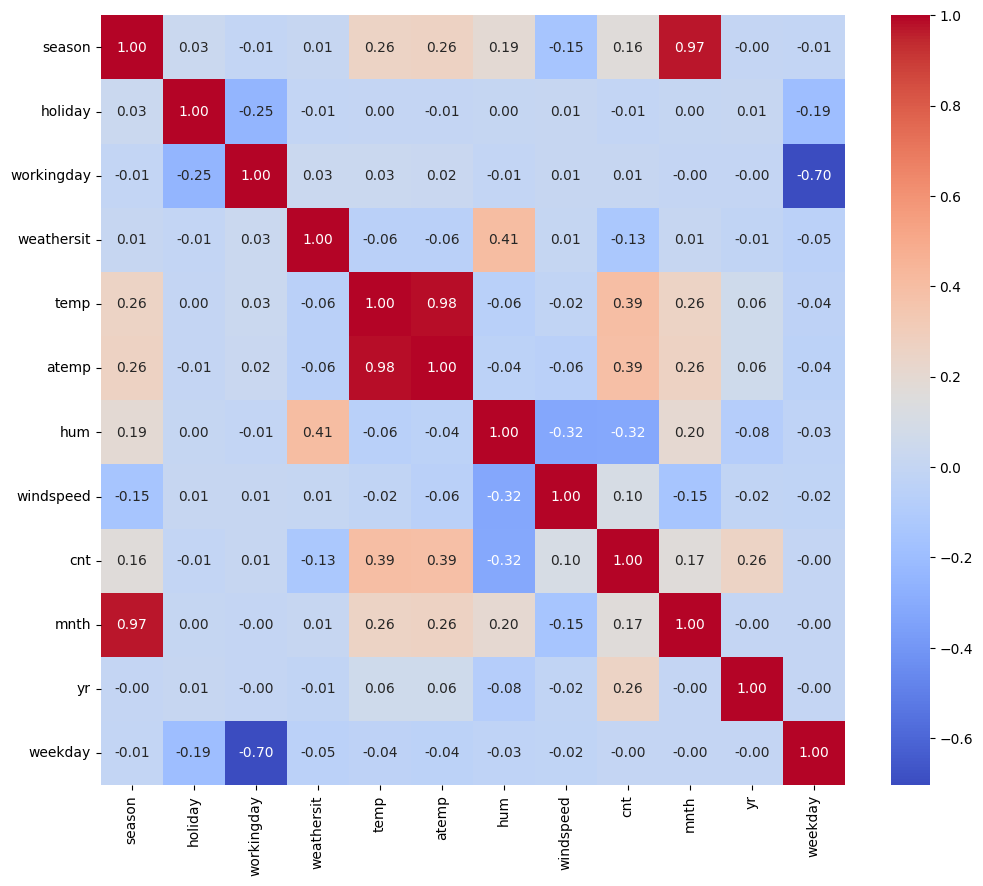

In [ ]:
correlation = df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

**Ответьте на вопрос**: с какими признаками количество прокатов коррелирует меньше всего (около 4 штуки). А с какими больше всего?

Ответ:

Меньше всего число прокатов коррелирует с `holiday`, `workingday`, `weekday` и `hum`. Больше всего — с `atemp` и `temp`.

### 3. Barpot

Постройте Bar-график суммарного количества прокатов велосипедов по месяцам за каждый год одновременно. (будет 24 столбика)



<Axes: xlabel='yr,mnth'>

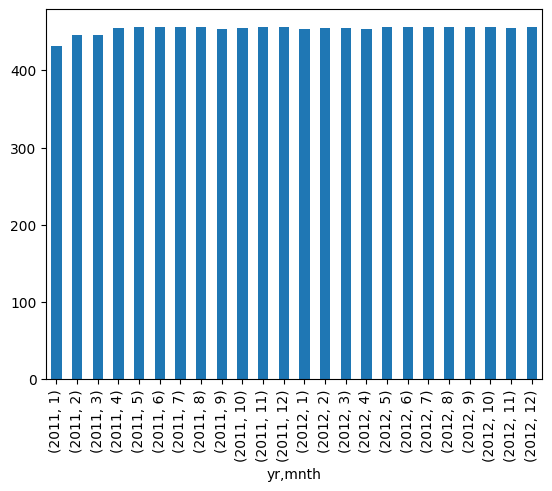

In [ ]:
df.groupby(["yr", "mnth"])["cnt"].count().plot.bar()

**Ответьте на вопрос:** почему в предыдущем графике была такая большая корреляция между количеством прокатов и годом?

Ответ:

В 2012 году велосипедами пользовались заметно чаще, чем в 2011 году. Поэтому признак года хорошо связан с общим количеством прокатов.

### 4. Countplot

Постройте countplot диаграммы для признаков `weekday`, `weathersit`,



<Axes: xlabel='weekday,weathersit'>

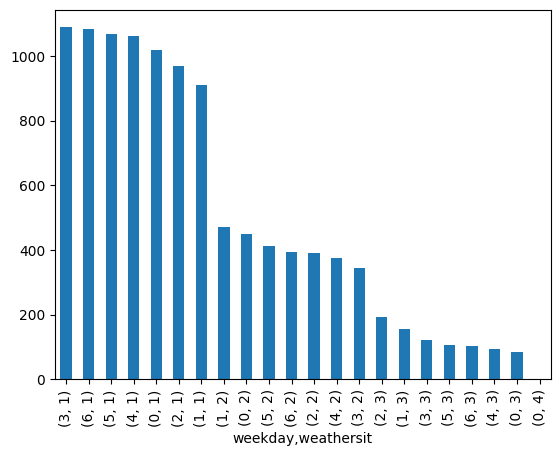

In [ ]:
data = df[["weekday", "weathersit"]].value_counts()
data.plot.bar()

**Ответьте на вопрос:** что вы можете сказать о том, как формировался этот датасет.



Ответ:

В датасете есть наблюдения почти за каждый день двух лет. В хорошую погоду аренды больше, в не зависимости от дня неделю, в плохую меньше.

**Ответьте на вопрос:** как называется распределение значений признака `weekday`?

Ответ:

Распределение значений `weekday` равномерное.

### 5. Распределение

Постройте распределение целевого признака.


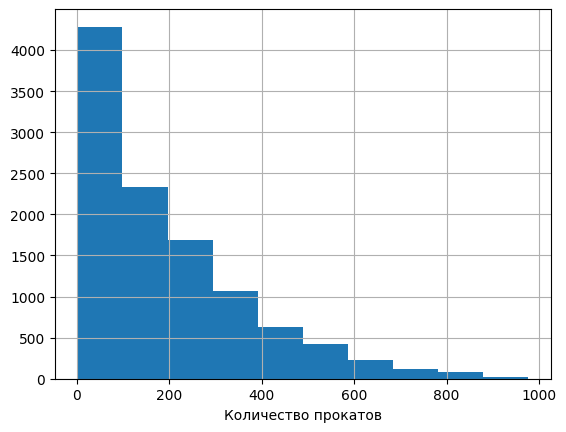

In [ ]:
df['cnt'].hist()
plt.xlabel('Количество прокатов')
plt.show()


**Ответьте на вопрос:** основываясь на графике, сколько приблизительно в среднем прокатов бывает в день?

Ответ:

В среднем бывает примерно 200 прокатов в день.

### 6. Совместное распределение признаков

Постройте график совместного распределения признаков температура и ощущение температуры.



array([[<Axes: title={'center': 'temp'}>,
        <Axes: title={'center': 'atemp'}>]], dtype=object)

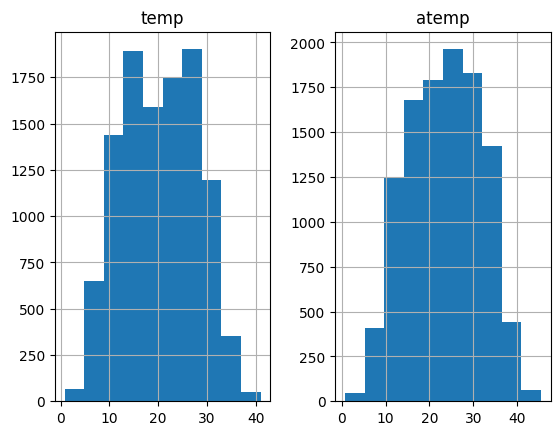

In [ ]:
df[["temp", "atemp"]].hist()

**Ответьте на вопрос:** вас в этом графике ничего не настораживает? Почему?

Ответ:

Нет.

### 7. Боксплот (ящик с усами)

Постройте график распределения (боксплот) количества прокатов велосипедов по месяцам в зависимости от того рабочий это день или нет.




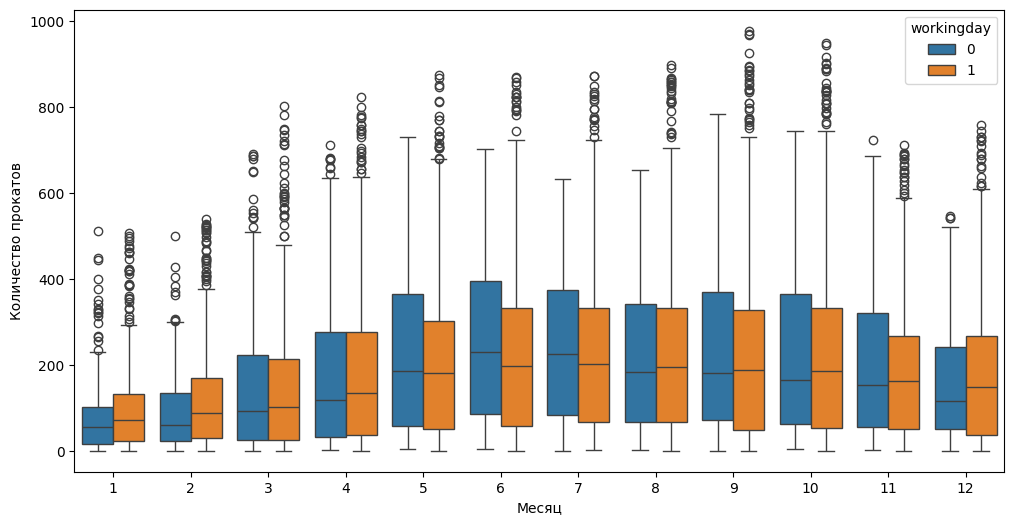

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='mnth', y='cnt', hue='workingday')
plt.xlabel('Месяц')
plt.ylabel('Количество прокатов')
plt.show()

**Ответьте на вопрос:** почему в некоторых месяцах чаще берут велосипеды в будний день, а в некоторые - в выходной.

Ответ:

В теплые месяцы чаще арендуют в выходные дни, скорее всего для отдыха.

## Комплексное задание №3. Визуальный анализ данных. Часть 2

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

  Attempting uninstall: seaborn
    Found existing installation: seaborn 0.13.2
    Uninstalling seaborn-0.13.2:
      Successfully uninstalled seaborn-0.13.2



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
colab = False # если работаете на своём компьютере, в локальной среде, поставьте False
if colab:
    from google.colab import drive
    drive.mount('/content/drive')

В этом задании Вам предлагается провести визуальный анализ датасета результатов экзаменов студентов  https://www.kaggle.com/spscientist/students-performance-in-exams.

Исходные данные загрузите самостоятельно!

In [ ]:
df = pd.read_csv("StudentsPerformance.csv")

df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


### Ход задания:

#### 1. Постройте 3 графика, показывающих распределение результатов экзаменов (каждый график на предмет).


Графики должны быть в одном ряду и у них должен быть общий заголовок "Результаты экзаменов".

Для результатов каждого экзамена посчитайте медианные значения.


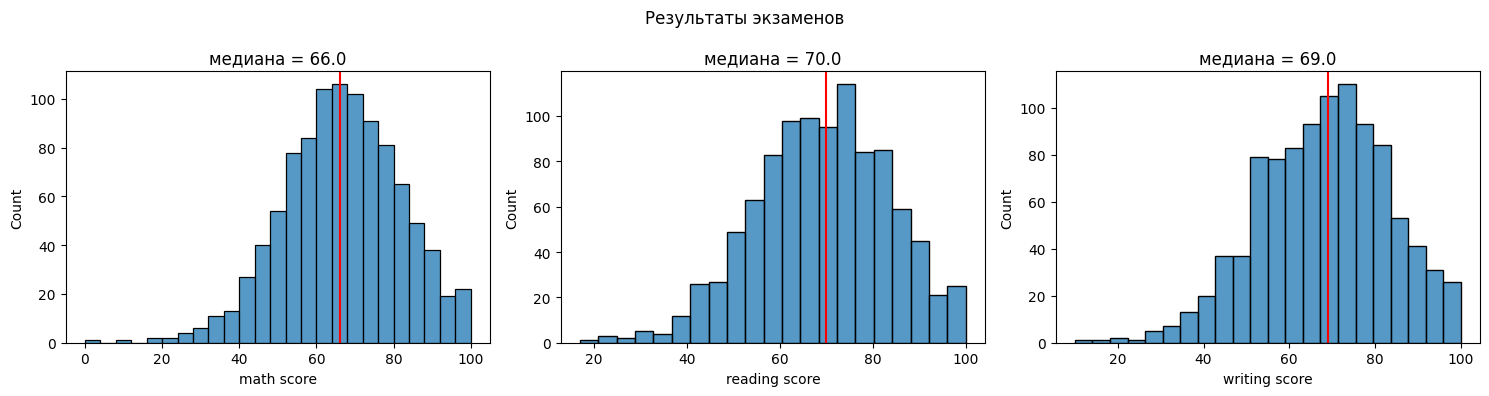

In [ ]:
subjects = ['math score', 'reading score', 'writing score']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for index in range(len(subjects)):
    subject = subjects[index]
    median = df[subject].median()
    sns.histplot(df[subject], ax=axes[index])
    axes[index].axvline(median, color='red')
    axes[index].set_title('медиана = ' + str(median))

fig.suptitle('Результаты экзаменов')
plt.tight_layout()
plt.show()

#### 2. Образование родителей
Какие уровни образование есть в столбце *'parental level of education'* и сколько строк в датафрейме соответствует каждому уровню?

Постройте график и ответьте на вопрос ниже

Отличаются ли баллы по математике у детей с разным образованием родителей?
Постройте график, где по оси Х находятся уровни образования родителей, а по У - баллы по математике.


parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

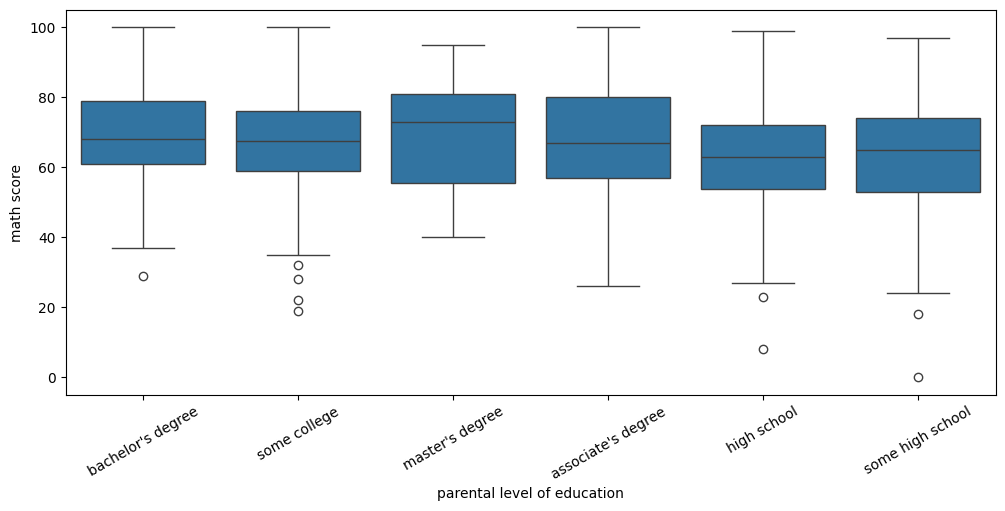

In [ ]:
education_count = df['parental level of education'].value_counts()
display(education_count)

plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='parental level of education', y='math score')
plt.xticks(rotation=30)
plt.show()

#### 3. Выведите число студенток, набравших больше 90 баллов по всем предметам.


In [ ]:
girls = df[(df['gender'] == 'female') &
           (df['math score'] > 90) &
           (df['reading score'] > 90) &
           (df['writing score'] > 90)]

print('Количество студенток, набравший больше 90 баллов по всем предметам:', len(girls))

Количество студенток, набравший больше 90 баллов по всем предметам: 17


#### 4. Сравните баллы у студентов разных полов. Используя agg() выведите минимальное, максимальное и медианное значение


In [ ]:
scores = ['math score', 'reading score', 'writing score']
df.groupby('gender')[scores].agg(['min', 'max', 'median'])

math score             reading score             writing score       \
              min  max median           min  max median           min  max   
gender                                                                       
female          0  100   65.0            17  100   73.0            10  100   
male           27  100   69.0            23  100   66.0            15  100   

               
       median  
gender         
female   74.0  
male     64.0

#### 5. Выясните, влияет ли обед и подготовка к тесту на средний балл студентов разного пола
###### (подсказка: используете  [pd.agg()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.agg.html))

In [ ]:
df['average score'] = df[['math score', 'reading score', 'writing score']].mean(axis=1)
df.groupby(['gender', 'lunch', 'test preparation course'])['average score'].agg(['mean'])

mean
gender lunch        test preparation course           
female free/reduced completed                69.528571
                    none                     59.501401
       standard     completed                77.479532
                    none                     70.961240
male   free/reduced completed                65.721311
                    none                     58.323810
       standard     completed                73.513274
                    none                     65.486043

#### 6. Постройте график, показывающий зависимость уровня образования родителей от их расы

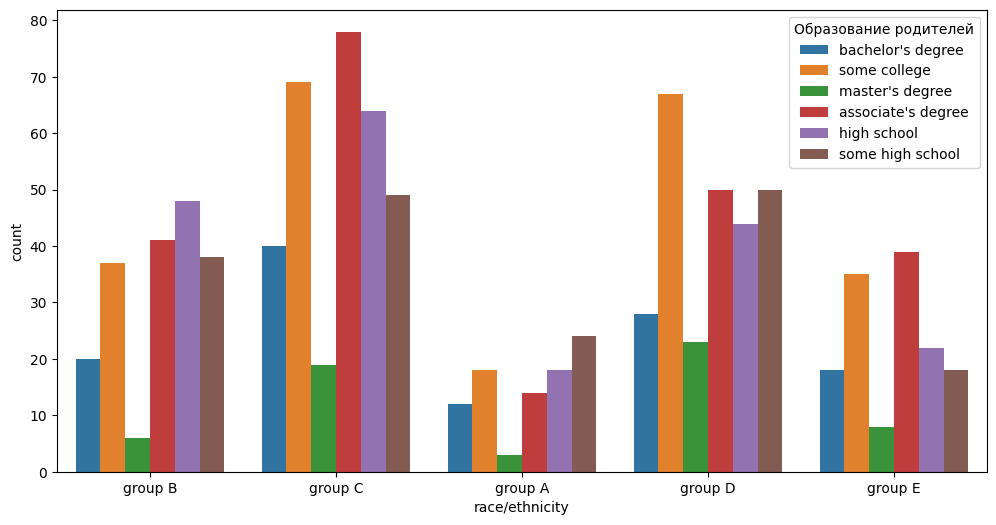

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='race/ethnicity', hue='parental level of education')
plt.legend(title='Образование родителей')
plt.show()

#### 7. Постройте график, показывающий зависимость прохождения подготовительного теста от уровня образования родителей.


Кто чаще ходит на курсы: дети, родители которых закончили только старшую школу, или дети, чьи родители получили степень бакалавра\магистра?

test preparation course,completed,none
parental level of education,,
associate's degree,0.369369,0.630631
bachelor's degree,0.389831,0.610169
high school,0.285714,0.714286
master's degree,0.338983,0.661017
some college,0.340708,0.659292
some high school,0.430168,0.569832


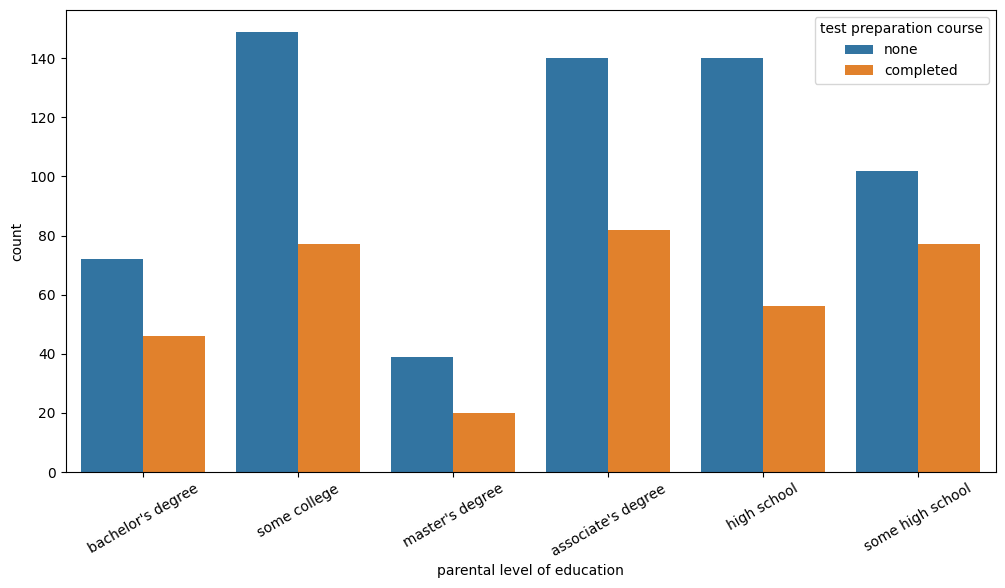

In [ ]:
preparation = pd.crosstab(df['parental level of education'], df['test preparation course'], normalize='index')
display(preparation)

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='parental level of education', hue='test preparation course')
plt.xticks(rotation=30)
plt.show()

#### 8. Постройте plot.pie, показывающий, сколько людей сдали\не сдали экзамен по математике.

Сдавшим считается человек, набравший 40 баллов.

###### Подсказка: создайте столбец в датафрейме, который содержит результат сдачи (сдал или не сдал)

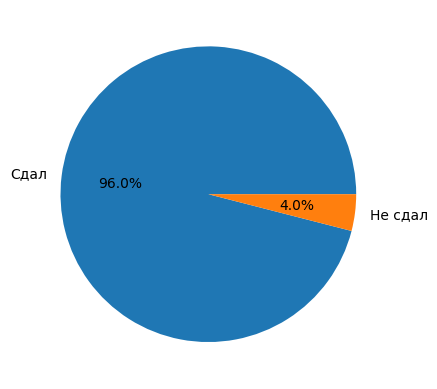

In [ ]:
df['math result'] = 'Сдал'
df.loc[df['math score'] < 40, 'math result'] = 'Не сдал'

df['math result'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.show()

#### 9. Постройте plot.pie, показывающий распределение студентов по оценкам

Оценки студентов выставляются по шкале:<br>
0  - 40 marks : grade E<br>
41 - 60 marks : grade D<br>
60 - 70 marks : grade C<br>
70 - 80 marks : grade B<br>
80 - 90 marks : grade A<br>
90 - 100 marks : grade O<br>

Для этого посчитайте сумму результатов за 3 экзамена и найдите среднее. Оценка выставляется по среднему значению. Если студент не сдал математику(даже если средний балл выше 40), он получает Е

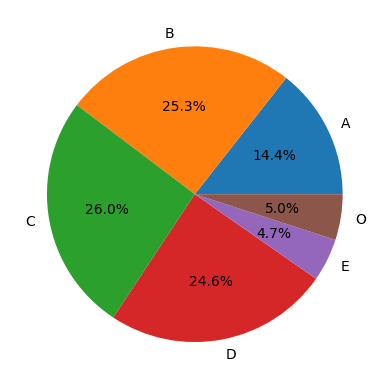

In [ ]:
df['average score'] = df[['math score', 'reading score', 'writing score']].mean(axis=1)

def get_grade(row):
    if row['math score'] < 40 or row['average score'] <= 40:
        return 'E'
    elif row['average score'] <= 60:
        return 'D'
    elif row['average score'] <= 70:
        return 'C'
    elif row['average score'] <= 80:
        return 'B'
    elif row['average score'] <= 90:
        return 'A'
    else:
        return 'O'

df['grade'] = df.apply(get_grade, axis=1)
df['grade'].value_counts().sort_index().plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.show()

#### 10. Постройте countplot, показывающий зависимость между итоговой оценкой студентов и его полом. Студенты какого пола получили больше оценок О, А, В

gender,female,male
grade,,
A,79,65
B,148,105
C,127,133
D,97,149
E,31,16
O,36,14


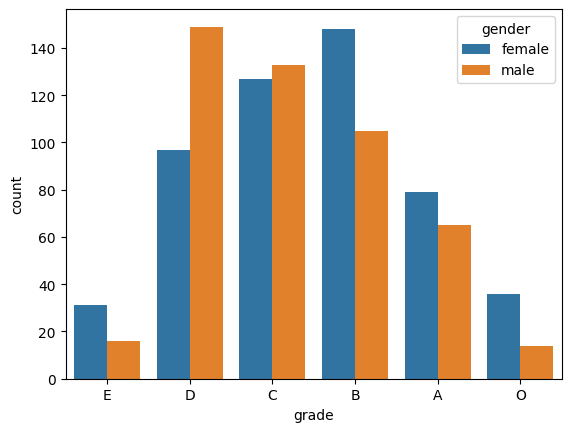

In [ ]:
display(pd.crosstab(df['grade'], df['gender']))

sns.countplot(data=df, x='grade', hue='gender', order=['E', 'D', 'C', 'B', 'A', 'O'])
plt.show()